# Principal Component Analysis (PCA) and Clustering Analysis on Wine Dataset

## Objective
The objective of this assignment is to:

1. Perform Exploratory Data Analysis (EDA) on the Wine dataset.
2. Apply Principal Component Analysis (PCA) for dimensionality reduction.
3. Perform clustering using K-Means on the original dataset.
4. Perform clustering using K-Means on PCA-transformed data.
5. Compare clustering performance before and after PCA.
6. Draw meaningful conclusions regarding the effectiveness of PCA in clustering tasks.

Dataset Used: Wine Dataset

In [1]:
# Importing Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

# Task 1: Exploratory Data Analysis (EDA)

In this section, we load the dataset and examine its structure, data types,
missing values, and statistical summary.

In [2]:
# Load Dataset

df = pd.read_csv("wine.csv")

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
# Dataset Shape

print("Rows and Columns :", df.shape)

Rows and Columns : (178, 14)


In [4]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
# Missing Values Check

df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

## No missing values were found in the dataset.
The dataset is clean and suitable for further analysis.

In [6]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Type,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoids,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


# The statistical summary provides information regarding:

- Mean
- Standard Deviation
- Minimum Values
- Maximum Values
- Quartiles

# This helps understand feature distribution and variability.

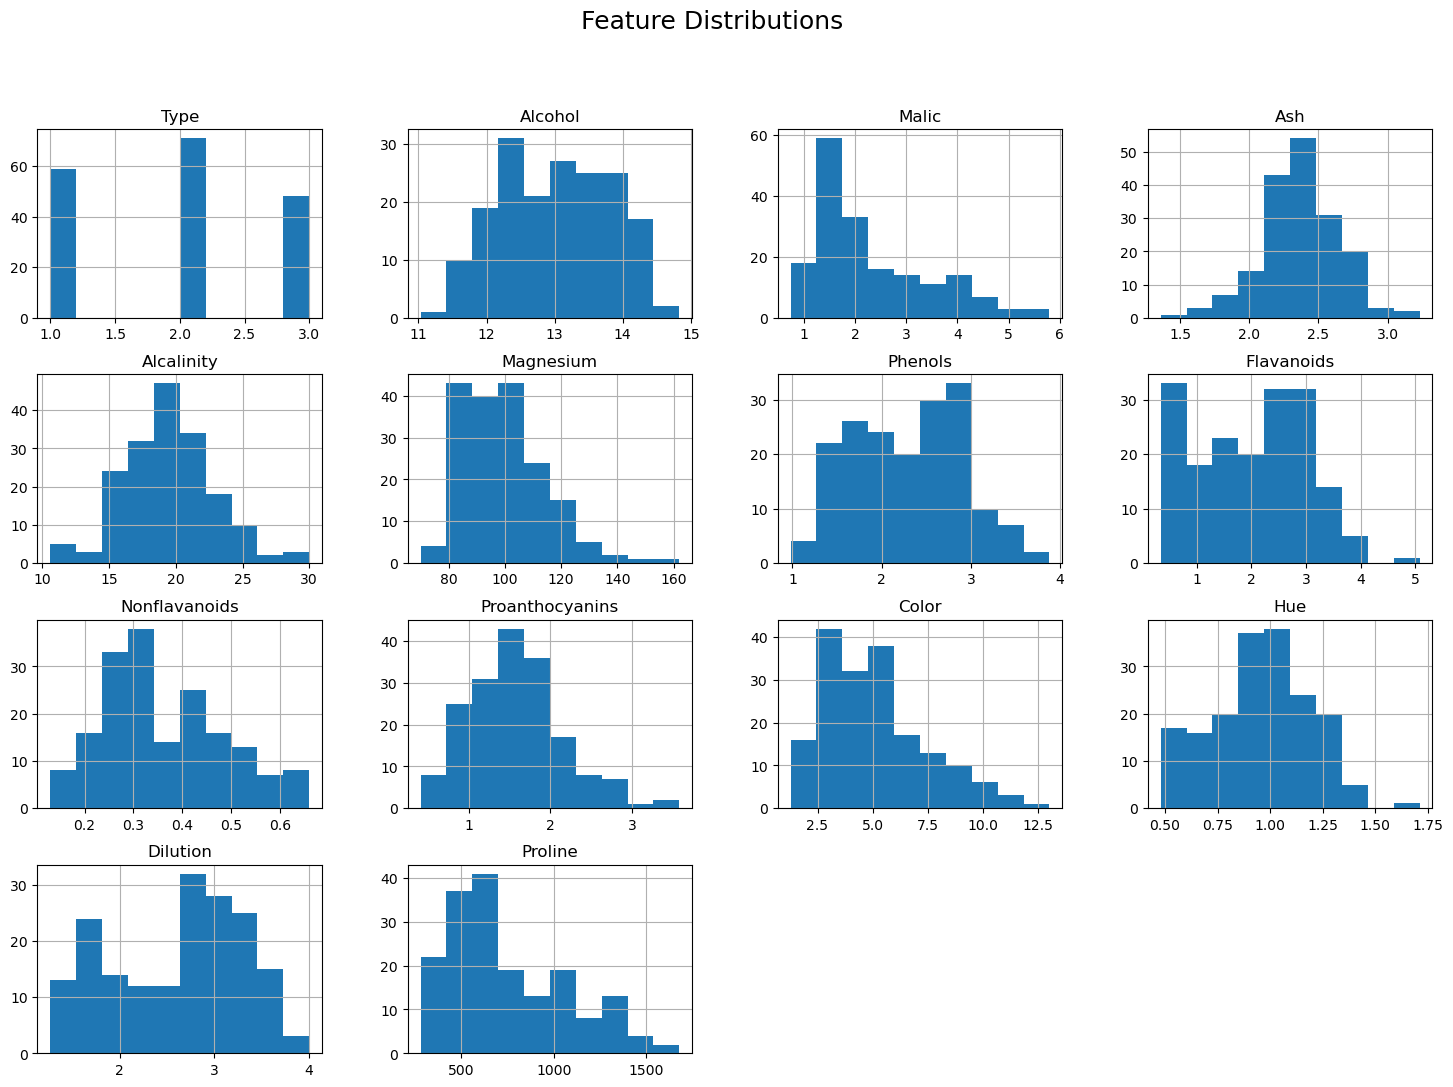

In [7]:
# Histogram for Feature Distribution

df.hist(figsize=(18,12))

plt.suptitle("Feature Distributions", fontsize=18)

plt.show()

### Histograms help visualize the distribution of each feature.

Observations:
- Some variables appear normally distributed.
- Some features exhibit skewness.
- Feature scaling will be required before PCA.

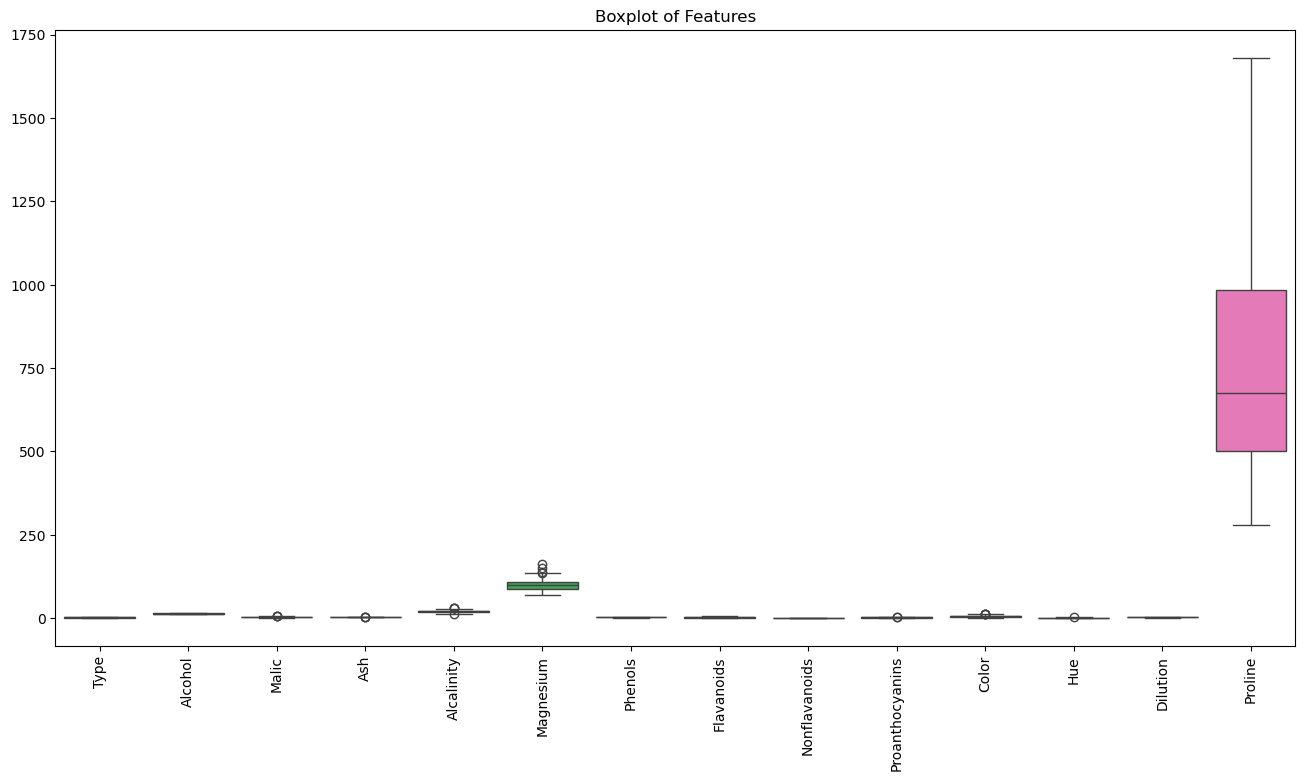

In [8]:
# Boxplots for Outlier Detection

plt.figure(figsize=(16,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplot of Features")

plt.show()

### Boxplots reveal potential outliers in certain features.

### Since PCA is sensitive to feature scales, standardization will be applied.

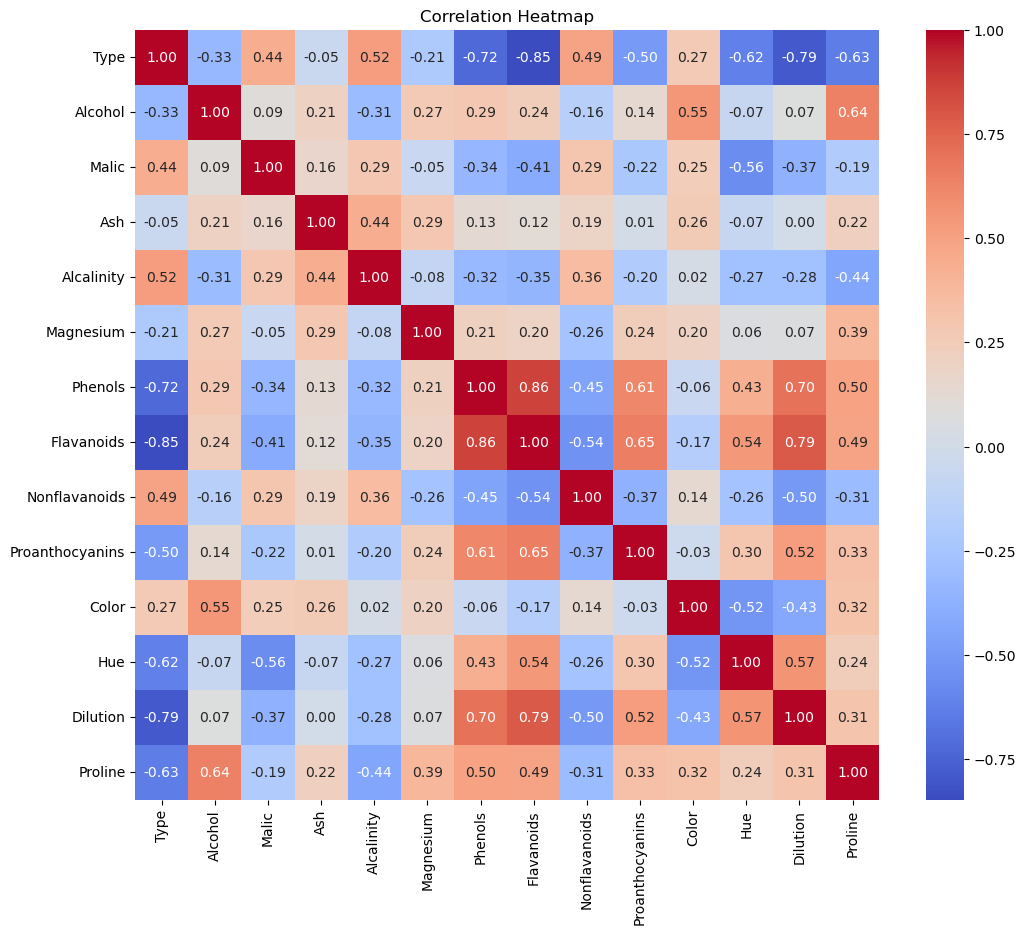

In [9]:
# Correlation Matrix

plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

#### The heatmap shows relationships between variables.

#### Highly correlated features indicate potential redundancy,
#### which PCA can reduce effectively.

# Task 2: Dimensionality Reduction using PCA

Before applying PCA, all features are standardized so that each variable
contributes equally to the analysis.

In [10]:
# Standardization

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_data[:5]

array([[-1.21394365,  1.51861254, -0.5622498 ,  0.23205254, -1.16959318,
         1.91390522,  0.80899739,  1.03481896, -0.65956311,  1.22488398,
         0.25171685,  0.36217728,  1.84791957,  1.01300893],
       [-1.21394365,  0.24628963, -0.49941338, -0.82799632, -2.49084714,
         0.01814502,  0.56864766,  0.73362894, -0.82071924, -0.54472099,
        -0.29332133,  0.40605066,  1.1134493 ,  0.96524152],
       [-1.21394365,  0.19687903,  0.02123125,  1.10933436, -0.2687382 ,
         0.08835836,  0.80899739,  1.21553297, -0.49840699,  2.13596773,
         0.26901965,  0.31830389,  0.78858745,  1.39514818],
       [-1.21394365,  1.69154964, -0.34681064,  0.4879264 , -0.80925118,
         0.93091845,  2.49144552,  1.46652465, -0.98187536,  1.03215473,
         1.18606801, -0.42754369,  1.18407144,  2.33457383],
       [-1.21394365,  0.29570023,  0.22769377,  1.84040254,  0.45194578,
         1.28198515,  0.80899739,  0.66335127,  0.22679555,  0.40140444,
        -0.31927553,  0.36

In [11]:
# Applying PCA on Full Dataset

pca = PCA()

pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_

In [12]:
# Explained Variance Table

variance_df = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance)+1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.395425,0.395425
1,2,0.178363,0.573787
2,3,0.103291,0.677078
3,4,0.066280,0.743358
4,5,0.062679,0.806037
5,6,0.048056,0.854093
6,7,0.039557,0.893650
7,8,0.025002,0.918652
8,9,0.021039,0.939691
9,10,0.018736,0.958427


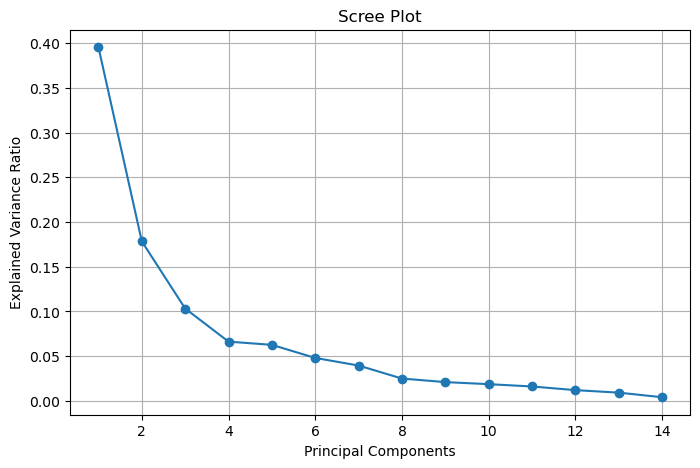

In [13]:
# Scree Plot

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

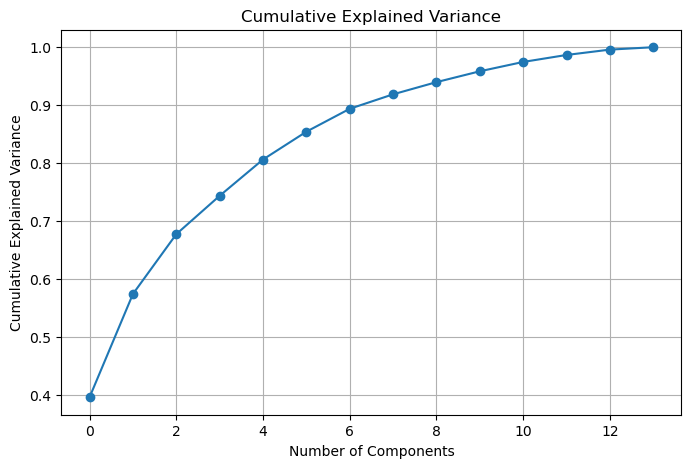

In [14]:
# Cumulative Explained Variance Plot

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.grid(True)

plt.show()

## Based on the cumulative explained variance plot,
## components explaining approximately 95% variance are selected.

In [15]:
# PCA with 95% Variance Retention

pca_final = PCA(n_components=0.95)

pca_data = pca_final.fit_transform(scaled_data)

print("Original Shape :", scaled_data.shape)

print("Reduced Shape :", pca_data.shape)

print("Number of Components Selected :", pca_final.n_components_)

Original Shape : (178, 14)
Reduced Shape : (178, 10)
Number of Components Selected : 10


## PCA successfully reduced dimensionality while retaining
## most of the important information from the dataset.

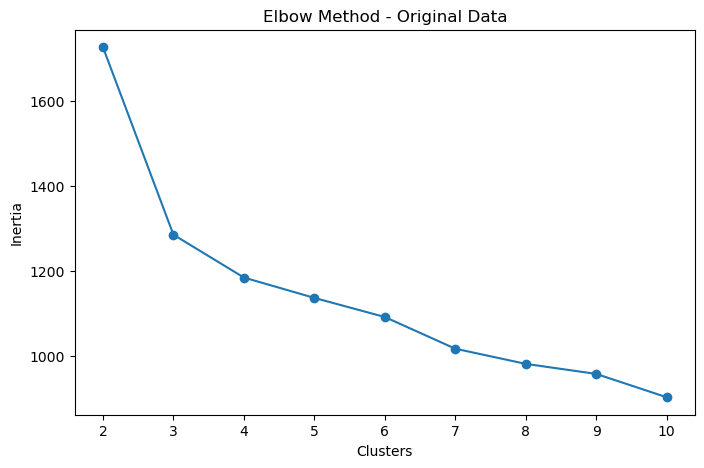

In [16]:
# Elbow Method

inertia = []

for k in range(2,11):
    
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    model.fit(scaled_data)
    
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method - Original Data")

plt.show()

In [17]:
# KMeans Clustering

kmeans_original = KMeans(
    n_clusters=3,
    random_state=42
)

original_clusters = kmeans_original.fit_predict(scaled_data)

In [18]:
# Evaluation Metrics

silhouette_original = silhouette_score(
    scaled_data,
    original_clusters
)

db_original = davies_bouldin_score(
    scaled_data,
    original_clusters
)

print("Silhouette Score :", silhouette_original)

print("Davies Bouldin Index :", db_original)

Silhouette Score : 0.30648398324833453
Davies Bouldin Index : 1.315707552261773


In [19]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

pca_clusters = kmeans_pca.fit_predict(pca_data)

In [20]:
silhouette_pca = silhouette_score(
    pca_data,
    pca_clusters
)

db_pca = davies_bouldin_score(
    pca_data,
    pca_clusters
)

print("Silhouette Score :", silhouette_pca)

print("Davies Bouldin Index :", db_pca)

Silhouette Score : 0.32292055407233006
Davies Bouldin Index : 1.2578453408449177


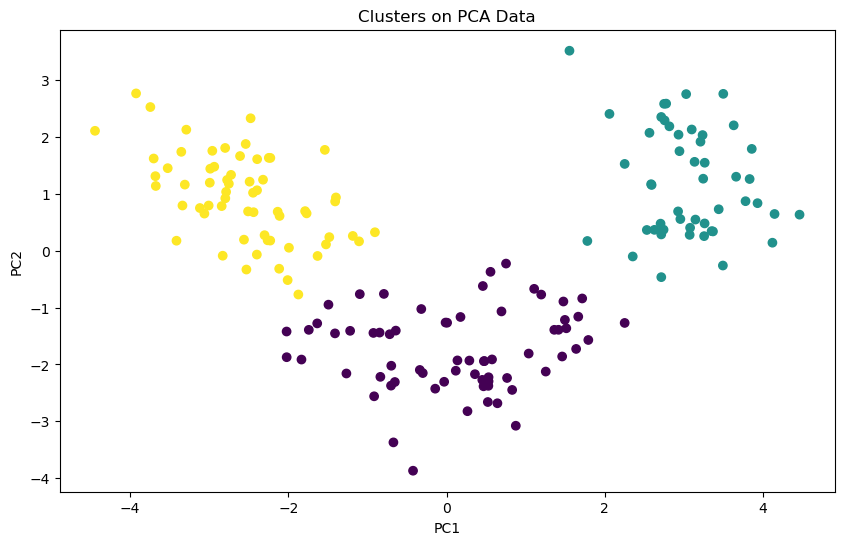

In [21]:
# PCA Cluster Visualization

plt.figure(figsize=(10,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=pca_clusters,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Clusters on PCA Data")

plt.show()

In [22]:
comparison = pd.DataFrame({
    "Metric":[
        "Silhouette Score",
        "Davies-Bouldin Index"
    ],
    
    "Original Data":[
        silhouette_original,
        db_original
    ],
    
    "PCA Data":[
        silhouette_pca,
        db_pca
    ]
})

comparison

,Metric,Original Data,PCA Data
0,Silhouette Score,0.306484,0.322921
1,Davies-Bouldin Index,1.315708,1.257845


# Conclusion

1. PCA successfully reduced the dimensionality of the Wine dataset while retaining approximately 95% of the variance.

2. K-Means clustering was applied on both the original dataset and PCA-transformed dataset.

3. Clustering performance was evaluated using:
   - Silhouette Score
   - Davies-Bouldin Index

4. PCA reduced computational complexity and improved visualization.

5. PCA can improve clustering performance when highly correlated variables exist.

6. For large datasets with many features, PCA is recommended before clustering.

7. The results demonstrate that dimensionality reduction can help simplify datasets while preserving important information.